<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/12.12_Cross-Validation_and_Model_Evaluation_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 12 - Evaluasi Silang dan Teknik Evaluasi Model (Cross-Validation and Model Evaluation Techniques)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 12 Cross-Validation and Model Evaluation Techniques** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

In [1]:
# Muat perpustakaan
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Muat kumpulan data
X, y = make_classification(n_samples=500, n_features=10, n_informative=8,
                           n_redundant=2, n_classes=2, random_state=2024)

## Bagaimana cara melakukannya...
Kami akan menerapkan Cross-Validation k-fold dan k-fold bertingkat untuk mengevaluasi model Logistic Regression.

In [2]:
# Inisialisasi k-fold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=2024)

# Ulangi lipatannya dan evaluasi
accuracies = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
print(f"Average accuracy (KFold): {np.mean(accuracies):.3f}")

# Gunakan k-fold bertingkat untuk pembagian kelas yang seimbang
strat_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)
strat_accuracies = []
for train_index, test_index in strat_kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    strat_accuracies.append(accuracy_score(y_test, y_pred))
print(f"Average accuracy (StratifiedKFold): {np.mean(strat_accuracies):.3f}")

Average accuracy (KFold): 0.756
Average accuracy (StratifiedKFold): 0.766


## Cara kerjanya...
Cross-Validation k-fold standar membagi data menjadi k bagian yang berukuran sama, melatih model pada k-1 bagian, dan mengujinya pada bagian yang tersisa—mengulangi proses ini sebanyak k kali. Namun pada permasalahan klasifikasi, terutama pada kelas yang tidak seimbang, hal ini dapat menyebabkan lipatan yang tidak mewakili sebaran kelas secara keseluruhan.
K-fold bertingkat memecahkan masalah ini dengan mempertahankan persentase sampel untuk setiap kelas di setiap lipatan. Hal ini memberikan perkiraan performa model yang lebih andal di seluruh kelas yang tidak seimbang.
Outputnya mencetak akurasi klasifikasi rata-rata di seluruh lipatan untuk kedua pendekatan. Dalam sebagian besar kasus ketidakseimbangan, k-fold bertingkat menghasilkan hasil evaluasi yang lebih stabil dan adil.

# Metode Validasi Silang Tingkat Lanjut
Saat kita bekerja dengan model yang kompleks atau kumpulan data yang kecil, strategi Cross-Validation dasar seperti k-fold mungkin tidak memberikan kontrol atau presisi yang kita perlukan. Dalam resep ini, kita akan mempelajari dua teknik tingkat lanjut—leave-one-out Cross-Validation (Cross-Validation) (LOOCV) dan nested Cross-Validation (Cross-Validation). LOOCV berguna ketika kita ingin memaksimalkan data yang terbatas, sementara Cross-Validation bertingkat membantu kita menyesuaikan hyperparameter tanpa kebocoran data antara pemilihan model dan evaluasi.

## Bersiap
Untuk memulai, kita akan memuat kumpulan data kecil dan menyiapkan pustaka yang diperlukan untuk LOOCV dan Cross-Validation bertingkat. Kami akan menggunakan Ridge Regression untuk demonstrasi, yang mendapat manfaat dari penyesuaian regularisasi.

In [3]:

# Muat perpustakaan
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge

# Muat kumpulan data
data = load_diabetes()
X = data.data
y = data.target

## Bagaimana cara melakukannya...
Kita akan membahas Cross-Validation yang tidak perlu dilakukan dan yang disarangkan dengan scikit-learn.

In [4]:
# Terapkan Cross-Validation Leave-One-Out dengan penilaian UMK
loo = LeaveOneOut()
model = Ridge(alpha=1.0)
scores = cross_val_score(model, X, y, cv=loo, scoring="neg_mean_squared_error")
print(f"LOOCV mean MSE: {-np.mean(scores):.3f}")

# Tentukan kisi untuk penyetelan hyperparameter
param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

# Terapkan Cross-Validation bertingkat menggunakan GridSearchCV (skor default baik untuk CV luar)
nested_scores = cross_val_score(
    GridSearchCV(Ridge(), param_grid, cv=5), X, y, cv=5
)
print(f"Nested CV mean score: {np.mean(nested_scores):.3f}")

LOOCV mean MSE: 3327.655
Nested CV mean score: 0.480


## Cara kerjanya...
Cross-Validation keluar-satu melakukan evaluasi model dengan melatih semua titik data kecuali satu, menggunakan titik tunggu untuk pengujian. Ini mengulangi hal ini untuk setiap titik data, memberikan perkiraan yang hampir tidak bias tetapi dengan biaya komputasi yang lebih tinggi.
Cross-Validation bertingkat berguna saat menyetel hyperparameter. Perulangan dalam melakukan pemilihan model (misalnya, Grid Search) sedangkan perulangan luar mengevaluasi kinerja model. Hal ini mencegah Overfitting pada set pengujian selama penyetelan hyperparameter, sehingga menghasilkan perkiraan performa generalisasi yang lebih jujur. Hasil yang dicetak akan mencakup skor rata-rata dari evaluasi LOOCV dan CV bertingkat. Karena CV bertingkat menangani penyetelan dan evaluasi secara terpisah, CV ini sering kali lebih disukai dalam alur pengembangan model.

# Menerapkan Validasi Silang di Scikit-Learn
Setelah kita memahami teori dan pentingnya Cross-Validation, langkah selanjutnya adalah mempraktikkannya. scikit-learn menawarkan alat yang disederhanakan untuk mengimplementasikan alur kerja Cross-Validation yang berbeda. Dalam resep ini, kita akan memandu penyiapan loop Cross-Validation dasar dan lanjutan menggunakan cross_val_score(), cross_validate(), dan GridSearchCV() untuk menilai dan membandingkan performa model.

## Bersiap
Kami akan menggunakan masalah klasifikasi sebagai dasar dan memuat alat yang diperlukan dari scikit-learn untuk menerapkan Cross-Validation.

In [5]:
# Muat perpustakaan
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV

# Muat dan siapkan kumpulan data
X, y = make_classification(n_samples=500, n_features=10, weights=[0.7, 0.3], random_state=2024)

## Bagaimana cara melakukannya...
Kami akan mendemonstrasikan tiga cara untuk melakukan Cross-Validation menggunakan API tingkat tinggi scikit-learn.

In [6]:
# Gunakan cross_val_score() untuk menghitung akurasi rata-rata
model = LogisticRegression()
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Mean accuracy: {np.mean(scores):.3f}")

# Gunakan cross_validate() untuk menghitung beberapa metrik
results = cross_validate(model, X, y, cv=5,
                         scoring=['accuracy', 'precision', 'recall', 'f1'])
print(f"Mean precision: {np.mean(results['test_precision']):.3f}")
print(f"Mean recall: {np.mean(results['test_recall']):.3f}")
print(f"Mean F1: {np.mean(results['test_f1']):.3f}")

# Gunakan GridSearchCV() untuk penyetelan hyperparameter dengan Cross-Validation
param_grid = {"C": [0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid.fit(X, y)
print(f"Best hyperparameter (C): {grid.best_params_['C']}")
print(f"Best accuracy: {grid.best_score_:.3f}")

Mean accuracy: 0.910


Mean precision: 0.875
Mean recall: 0.820
Mean F1: 0.845
Best hyperparameter (C): 0.1
Best accuracy: 0.918


## Cara kerjanya...
cross_val_score() menyediakan cara cepat untuk mengevaluasi model dengan satu metrik menggunakan Cross-Validation. cross_validate() lebih fleksibel, memungkinkan beberapa metrik diambil secara bersamaan.
GridSearchCV() mengintegrasikan Cross-Validation dengan pencarian hyperparameter. Ia melakukan pelatihan model dan evaluasi pada setiap kombinasi hyperparameter tertentu dan memilih yang terbaik berdasarkan metrik penilaian.
Pendekatan ini membantu mengurangi Overfitting dan meningkatkan generalisasi dengan memberikan gambaran yang lebih kuat tentang bagaimana kinerja model di berbagai subkumpulan data.

# Teknik Pemilihan Model
Setelah kami mengevaluasi model kami menggunakan Cross-Validation, langkah selanjutnya adalah memilih model terbaik untuk diterapkan. Teknik pemilihan model membantu kita membandingkan berbagai algoritme dan konfigurasi dengan cara yang kuat secara statistik. Dalam resep ini, kita akan menggunakan penelusuran grid dan penelusuran acak untuk melakukan penyetelan hyperparameter dan memilih model optimal berdasarkan skor Cross-Validation.

## Bersiap
Kami akan menggunakan tugas klasifikasi dan membandingkan kekuatan regularisasi yang berbeda untuk Logistic Regression menggunakan strategi pencarian yang menyeluruh dan acak.

In [7]:
# Muat perpustakaan
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score

# Muat dan pisahkan kumpulan data
X, y = make_classification(n_samples=500, n_features=10, weights=[0.7, 0.3], random_state=2024)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

## Bagaimana cara melakukannya...
Kami akan menyiapkan dan membandingkan GridSearchCV dan RandomizedSearchCV untuk menemukan kekuatan regularisasi terbaik untuk Logistic Regression.

In [8]:
# Gunakan GridSearchCV untuk mengevaluasi semua kombinasi di grid parameter
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print(f"GridSearchCV best C: {grid.best_params_['C']}")

# Gunakan RandomizedSearchCV untuk mengevaluasi sampel parameter acak
from scipy.stats import loguniform
param_dist = {"C": loguniform(1e-3, 1e2)}
random_search = RandomizedSearchCV(LogisticRegression(), param_distributions=param_dist,
                                    n_iter=10, cv=5, scoring='accuracy', random_state=2024)
random_search.fit(X_train, y_train)
print(f"RandomizedSearchCV best C: {random_search.best_params_['C']:.4f}")

# Evaluasi kinerja model akhir
final_model = random_search.best_estimator_
y_pred = final_model.predict(X_test)
print(f"Final accuracy on test set: {accuracy_score(y_test, y_pred):.3f}")

GridSearchCV best C: 0.1


RandomizedSearchCV best C: 0.1744
Final accuracy on test set: 0.940


## Cara kerjanya...
GridSearchCV() melakukan pencarian menyeluruh di seluruh grid hyperparameter yang ditentukan. Meskipun komprehensif, hal ini dapat menjadi mahal secara komputasi seiring bertambahnya jumlah parameter.
RandomizedSearchCV() mengambil sampel sejumlah kombinasi parameter dari distribusi yang kami tentukan. Hal ini sering kali lebih efisien dan memberikan hasil yang sebanding dengan evaluasi yang lebih sedikit.
Kami menggunakan alat ini untuk mengidentifikasi konfigurasi model yang menghasilkan performa terbaik selama Cross-Validation dan kemudian memvalidasinya pada data uji yang tidak terlihat.

# Mengevaluasi Generalisasi Model
Model yang berkinerja baik pada set pelatihan dan validasi tidak selalu dapat digeneralisasi dengan baik pada data yang tidak terlihat. Resep ini berfokus pada teknik untuk menilai dan memastikan kemampuan generalisasi model pembelajaran mesin. Kami akan mempelajari Learning Curve, kurva validasi, dan strategi Cross-Validation yang membantu mencegah Overfitting dan mendukung pengembangan model yang kuat.

## Bersiap
Kami akan menggunakan kumpulan data klasifikasi sintetik dan Logistic Regression untuk menunjukkan bagaimana performa model berubah dengan jumlah data latih yang berbeda dan kompleksitas model yang bervariasi.

In [9]:
# Muat perpustakaan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, validation_curve

# Muat kumpulan data
X, y = make_classification(n_samples=1000, n_features=20, weights=[0.7, 0.3], random_state=2024)

## Bagaimana cara melakukannya...
Kita akan mulai dengan memplot Learning Curve untuk memahami bagaimana performa model seiring bertambahnya ukuran pelatihan, lalu memplot kurva validasi untuk mengevaluasi performa model di berbagai nilai hyperparameter utama.

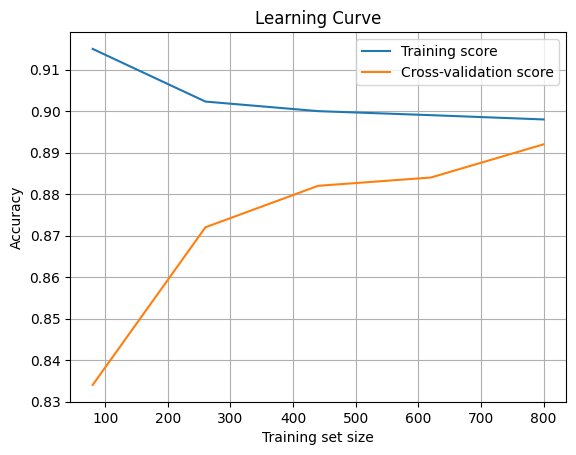

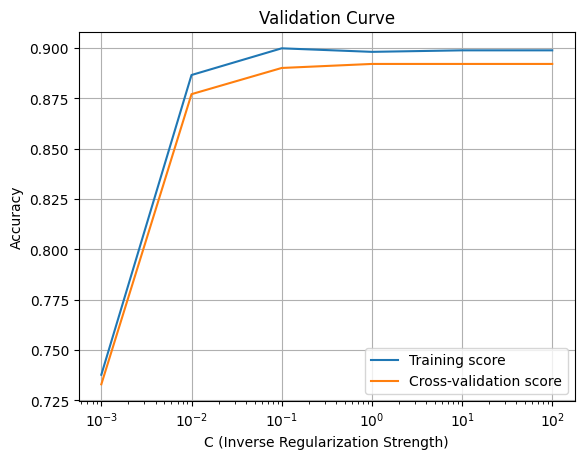

In [10]:
# Plot Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(), X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5), random_state=2024)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

# Plot kurva validasi
param_range = np.logspace(-3, 2, 6)
train_scores, test_scores = validation_curve(
    LogisticRegression(), X, y, param_name="C", param_range=param_range,
    cv=5, scoring='accuracy')

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.semilogx(param_range, train_mean, label='Training score')
plt.semilogx(param_range, test_mean, label='Cross-validation score')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend()
plt.grid(True)
plt.show()

## Cara kerjanya...
Learning Curve menggambarkan bagaimana akurasi pelatihan dan validasi berkembang seiring dengan semakin banyaknya data latih yang digunakan. Kesenjangan antara dua garis sering kali menandakan Overfitting, sedangkan konvergensi menunjukkan generalisasi yang baik.
Kurva validasi membantu mengidentifikasi apakah model tersebut Underfitting atau Overfitting pada tingkat kompleksitas model yang berbeda. Misalnya, nilai C yang kecil menyebabkan regularisasi yang kuat, yang berpotensi menyebabkan Underfitting pada data, sedangkan nilai C yang besar mengurangi regularisasi dan dapat menyebabkan Overfitting.
Diagnostik ini memungkinkan kami membuat keputusan berdasarkan data tentang konfigurasi model dan kecukupan kumpulan data.

# Latihan Praktis dalam Validasi Silang dan Evaluasi
Di bagian terakhir ini, kita akan melakukan latihan praktis yang melibatkan pembuatan, penyesuaian, dan evaluasi model menggunakan Cross-Validation dan metrik kinerja. Latihan ini dirancang untuk memperkuat konsep yang dieksplorasi sepanjang bab ini, termasuk pemilihan model, penyesuaian hyperparameter, dan evaluasi generalisasi. Dengan menyelesaikan latihan ini, kita akan memperkuat pemahaman kita tentang cara menilai kinerja model secara efektif dan memilih model terbaik untuk aplikasi dunia nyata.

## Latihan 1: Validasi Silang Model Logistic Regression
Kami akan mengevaluasi Classifier Logistic Regression menggunakan Cross-Validation k-fold dan melaporkan beberapa metrik.

### Langkah Penerapan:

In [11]:
# Memuat perpustakaan
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

# Muat kumpulan data
X, y = make_classification(n_samples=500, n_features=10, random_state=2024)

# Cross-Validation dan kumpulkan metrik
model = LogisticRegression()
results = cross_validate(model, X, y, cv=5, scoring=["accuracy", "precision", "recall", "f1"])

for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1"]:
    print(f"{metric}: {results[metric].mean():.3f}")

test_accuracy: 0.896
test_precision: 0.896
test_recall: 0.895
test_f1: 0.895


## Latihan 2: Menyesuaikan Hyperparameter dengan Pencarian Grid
Kami akan melakukan penyetelan hyperparameter menggunakan GridSearchCV dan membandingkan hasilnya.

### Langkah Penerapan:

In [12]:
# Memuat perpustakaan
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Muat dan pisahkan kumpulan data
X, y = make_classification(n_samples=500, n_features=10, random_state=2024)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Lakukan pencarian jaringan
param_grid = {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)
print(f"Best parameters: {grid.best_params_}")

# Evaluasi set tes
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

Best parameters: {'C': 0.1, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.94      0.86      0.89        84
           1       0.84      0.92      0.88        66

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150



## Latihan 3: Menilai Generalisasi Model dengan Kurva Pembelajaran dan Validasi
Kami akan menggunakan learning_curve dan validation_curve untuk memvisualisasikan bagaimana performa model bervariasi menurut ukuran pelatihan dan kompleksitas model.

### Langkah Penerapan:

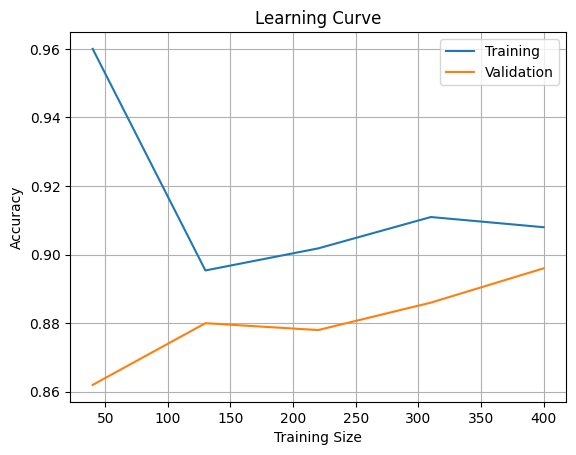

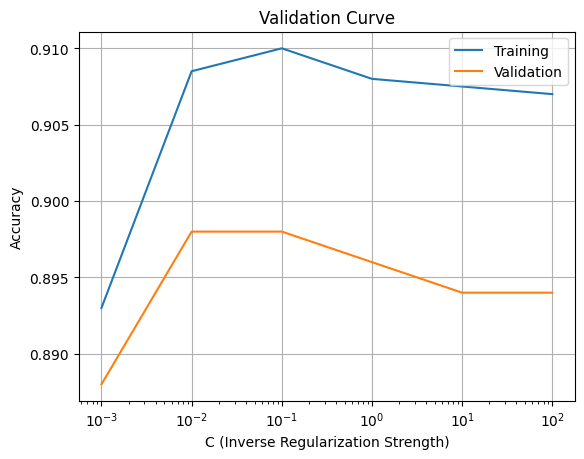

In [13]:
# Memuat perpustakaan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, validation_curve

# Plot Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(), X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5), random_state=2024)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation")
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot kurva validasi
param_range = np.logspace(-3, 2, 6)
train_scores, test_scores = validation_curve(
    LogisticRegression(), X, y, param_name="C", param_range=param_range,
    cv=5, scoring='accuracy')

plt.semilogx(param_range, train_scores.mean(axis=1), label="Training")
plt.semilogx(param_range, test_scores.mean(axis=1), label="Validation")
plt.title("Validation Curve")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita mempelajari metode validasi dan optimasi model machine learning secara mendalam:
* **Cross-Validation (CV):** Menggunakan K-Fold, Stratified K-Fold (untuk kelas imbalanced), dan Leave-One-Out untuk estimasi performa model yang stabil dan objektif.
* **Hyperparameter Search:** Menerapkan `GridSearchCV` untuk pencarian parameter secara menyeluruh dan `RandomizedSearchCV` untuk efisiensi komputasi pada ruang parameter yang luas.
* **Analisis Bias-Varians:** Menganalisis kurva pembelajaran (*Learning Curves*) untuk melihat dampak volume data latih dan kurva validasi (*Validation Curves*) untuk memahami dampak nilai hyperparameter tertentu terhadap performa model.

#### 2. Pandangan ke Depan
Proses evaluasi yang ketat menjamin bahwa model yang kita latih siap digunakan pada data dunia nyata tanpa risiko overfitting. Di **Bab 13** (bab terakhir), kita akan mempelajari langkah final dalam siklus machine learning: melakukan serialisasi (penyimpanan) model dan menyebarkannya (*deployment*) ke lingkungan produksi agar dapat memproses prediksi secara real-time.